In [1]:
from abc import ABC, abstractmethod
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv('Fertilizer Prediction.csv')

In [16]:
print("Data Types:")
print(df.dtypes)
print("\nNon-null Counts:")
print(df.count())
print("\nData types and non null Counts:")
print(df.info())

print("Summary Statistics (Numerical Features:")
print(df.describe())
print("\nSummary Statistics (Categorical Features:")
print(df.describe(include=["O"]))

print("\n First 5 rows ")
print(df.head())

Data Types:
temparature         int64
humidity            int64
moisture            int64
soil_type          object
crop_type          object
nitrogen            int64
potassium           int64
phosphorous         int64
fertilizer_name    object
dtype: object

Non-null Counts:
temparature        99
humidity           99
moisture           99
soil_type          99
crop_type          99
nitrogen           99
potassium          99
phosphorous        99
fertilizer_name    99
dtype: int64

Data types and non null Counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99 entries, 0 to 98
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   temparature      99 non-null     int64 
 1   humidity         99 non-null     int64 
 2   moisture         99 non-null     int64 
 3   soil_type        99 non-null     object
 4   crop_type        99 non-null     object
 5   nitrogen         99 non-null     int64 
 6   potassium  

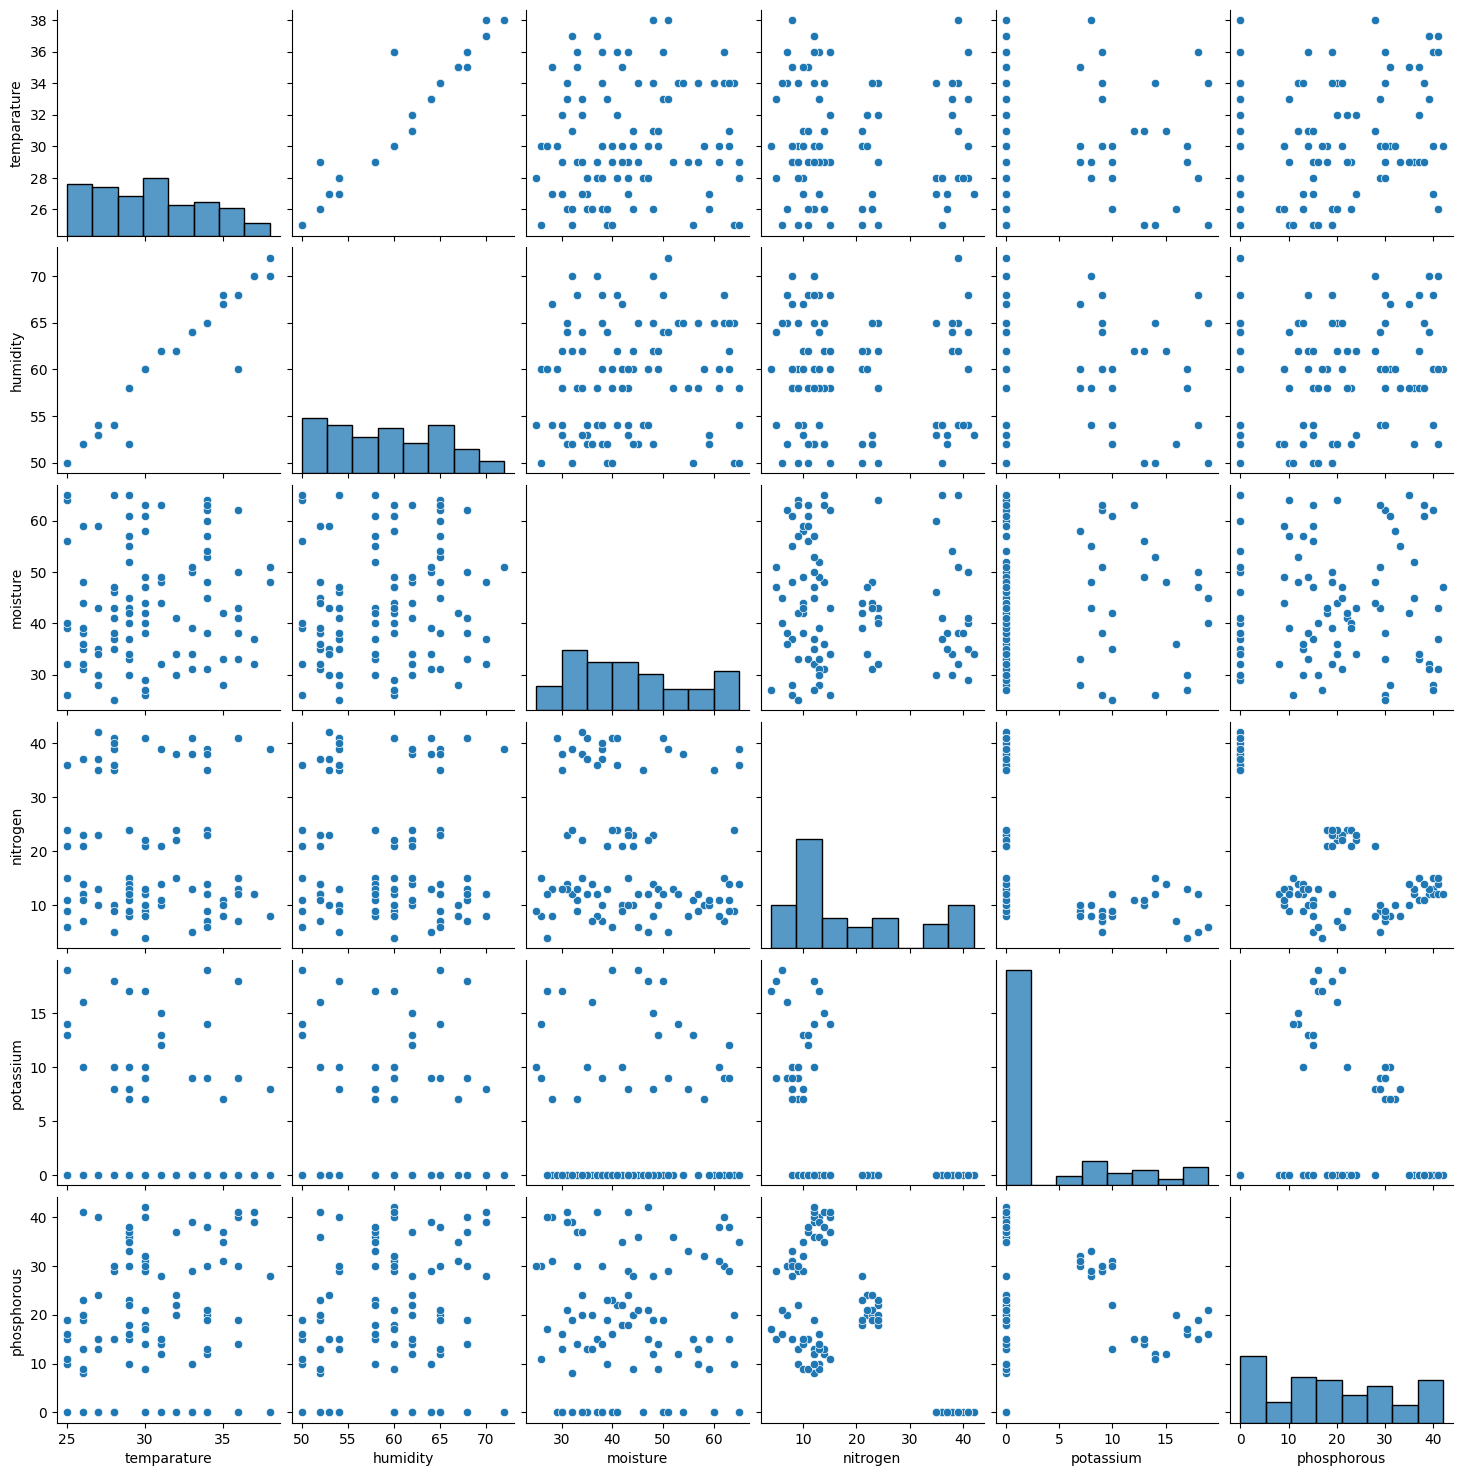

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


sns.pairplot(df)
plt.show()

In [18]:

df.columns = df.columns.str.lower().str.replace(" ", "_")  # Converts "crop type" -> "crop_type"

def get_column_types(df):


    numerical_columns = []
    categorical_columns = []

    for column in df.columns:
        # Check if the column is numeric
        if pd.api.types.is_numeric_dtype(df[column]):
            # Treat binary columns as categorical
            if df[column].nunique() == 2 and sorted(df[column].unique()) == [0, 1]:
                categorical_columns.append(column)
            else:
                numerical_columns.append(column)
        else:
            categorical_columns.append(column)

    return numerical_columns, categorical_columns

numerical_columns, categorical_columns = get_column_types(df)

print("numerical_columns: " , numerical_columns)
print("categorical_columns: ", categorical_columns)

print("Columns in DataFrame:", df.columns.tolist())


numerical_columns:  ['temparature', 'humidity', 'moisture', 'nitrogen', 'potassium', 'phosphorous']
categorical_columns:  ['soil_type', 'crop_type', 'fertilizer_name']
Columns in DataFrame: ['temparature', 'humidity', 'moisture', 'soil_type', 'crop_type', 'nitrogen', 'potassium', 'phosphorous', 'fertilizer_name']


In [22]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer



X = df[['temparature', 'humidity', 'moisture', 'nitrogen', 'potassium', 'phosphorous', 'soil_type', 'crop_type']]
y = df['fertilizer_name']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

numeric_features = X.select_dtypes(include=['number']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(), categorical_features)
    ]
)

In [23]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)


In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.pipeline import Pipeline

# Define models to compare
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100),
    "SVC (Linear Kernel)": SVC(kernel='linear'),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')
}


# Loop through models, train, predict, and evaluate
for model_name, model in models.items():
    pipeline = Pipeline([
        ("preprocess", preprocessor),
        ("classifier", model)
    ])

    # Train model
    pipeline.fit(X_train, y_train_encoded)

    # Predict
    y_pred = pipeline.predict(X_test)

    # Evaluate
    print(f"🚀 Model: {model_name}")
    print("Accuracy:", round(accuracy_score(y_test_encoded, y_pred) * 100, 2))
    print("\nClassification Report:\n", classification_report(y_test_encoded, y_pred))
    print("=" * 50)


🚀 Model: Logistic Regression
Accuracy: 95.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.50      0.67         2
           1       0.50      1.00      0.67         1
           3       1.00      1.00      1.00         1
           4       1.00      1.00      1.00         5
           5       1.00      1.00      1.00         5
           6       1.00      1.00      1.00         6

    accuracy                           0.95        20
   macro avg       0.92      0.92      0.89        20
weighted avg       0.97      0.95      0.95        20

🚀 Model: Random Forest
Accuracy: 95.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.50      0.67         2
           1       1.00      1.00      1.00         1
           2       0.00      0.00      0.00         0
           3       1.00      1.00      1.00         1
           4       1.00      1.00      1.00         5


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.p

🚀 Model: SVC (Linear Kernel)
Accuracy: 100.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         1
           3       1.00      1.00      1.00         1
           4       1.00      1.00      1.00         5
           5       1.00      1.00      1.00         5
           6       1.00      1.00      1.00         6

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20

🚀 Model: K-Nearest Neighbors
Accuracy: 75.0

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.50      1.00      0.67         1
           2       0.00      0.00      0.00         0
           3       0.50      1.00      0.67         1
           4       0.80      0.80      0.80    

In [25]:
# XGBoost performed best
from xgboost import XGBClassifier
model = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
      ("preprocess", preprocessor),
      ("classifier", model)
  ])

pipeline.fit(X_train, y_train_encoded)



/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [11:46:10] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['temparature', 'humidity',
                                                   'moisture', 'nitrogen',
                                                   'potassium',
                                                   'phosphorous']),
                                                 ('cat', OneHotEncoder(),
                                                  ['soil_type',
                                                   'crop_type'])])),
                ('classifier',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=N...
                               feature_types=None, gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None,
                               objective='multi:softprob', ...))])

In [26]:
import joblib

joblib.dump(pipeline, "model7.pkl")
print("Model and preprocessor saved successfully!")


Model and preprocessor saved successfully!


In [27]:
import joblib
from sklearn.preprocessing import LabelEncoder

# Encode labels
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)

# Save the label encoder
joblib.dump(label_encoder, "label_encoder7.pkl")


['label_encoder7.pkl']

In [ ]:
label_mapping = {index: label for index, label in enumerate(label_encoder.classes_)}
print(label_mapping)

pipeline = joblib.load("model_pipeline.pkl")


predictions = pipeline.predict(X_test)